# 04 — Model Evaluation & Selection

## KKBOX Customer Churn Prediction Platform

### Objective

Notebook này phân tích **QT5 — Model Evaluation & Selection**.

QT4 đã xác định:

- Primary candidate: **LightGBM**
- Secondary candidate: **Random Forest**

QT5 tập trung vào:

- Validation PR-AUC và ROC-AUC.
- Precision-Recall Curve.
- ROC Curve.
- Threshold analysis.
- Precision / Recall / F1.
- Confusion Matrix.
- Probability calibration.
- Error analysis.
- Feature importance.
- Model + threshold locking.
- Final Test evaluation.

> Notebook không train lại model.


In [21]:
import json

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import (
    calibration_curve,
)

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
)

from kkbox_churn_prediction.config import (
    EVALUATION_RESULTS_PATH,
    FEATURE_IMPORTANCE_PATH,
    FINAL_MODEL_CONFIG_PATH,
    TEST_PREDICTIONS_PATH,
    THRESHOLD_ANALYSIS_PATH,
    VALIDATION_PREDICTIONS_PATH,
)

pd.set_option(
    "display.max_columns",
    None,
)

pd.set_option(
    "display.float_format",
    "{:.4f}".format,
)


## 1. Load Validation Artifacts

Trước khi chạy notebook:

```bash
uv run python scripts/evaluate_model.py --validation-only
```

Lệnh này chỉ đánh giá Validation và chưa sử dụng Test.


In [22]:
with open(
    EVALUATION_RESULTS_PATH,
    encoding="utf-8",
) as file:
    evaluation_results = (
        json.load(file)
    )

evaluation_results


{'selected_model_candidate': 'lightgbm',
 'test_evaluated': True,
 'validation': {'probability_metrics': {'pr_auc': 0.9344557863761336,
   'roc_auc': 0.9897519072450893,
   'brier_score': 0.032100620002908385},
  'threshold_0_5': {'threshold': 0.5,
   'precision': 0.7197737449917512,
   'recall': 0.9325190839694657,
   'f1': 0.8124501197126895,
   'tn': 127788,
   'fp': 4756,
   'fn': 884,
   'tp': 12216,
   'predicted_positive_rate': 0.11653071873884266},
  'max_f1': {'threshold': 0.8411917297941325,
   'precision': 0.8596923536439666,
   'recall': 0.878854961832061,
   'f1': 0.8691680507322965,
   'tn': 130665,
   'fp': 1879,
   'fn': 1587,
   'tp': 11513,
   'predicted_positive_rate': 0.09195023481914806},
  'recall_80': {'threshold': 0.9353096724772832,
   'precision': 0.9107577337504345,
   'recall': 0.8000763358778626,
   'f1': 0.8518368010403121,
   'tn': 131517,
   'fp': 1027,
   'fn': 2619,
   'tp': 10481,
   'predicted_positive_rate': 0.07901458350498476}},
 'selected_model':

In [23]:
validation_predictions = (
    pd.read_parquet(
        VALIDATION_PREDICTIONS_PATH
    )
)

threshold_table = (
    pd.read_parquet(
        THRESHOLD_ANALYSIS_PATH
    )
)

feature_importance = (
    pd.read_parquet(
        FEATURE_IMPORTANCE_PATH
    )
)

validation_predictions.head()


,msno,is_churn,churn_probability,prediction,error_type
0,MNRUD2pAtKpbaPsD2bJqhwKQsIt06ZkosKVWXFZI2TQ=,0,0.0009,0,true_negative
1,VNRkKmdNl2eFCnBAYOvJTWfjDZvKMpsUjVQKS9EZXwE=,0,0.0488,0,true_negative
2,5sgOqrVgjFOnLz/ejNnMDS30C+NLUWhrwltB3OguPxk=,0,0.0003,0,true_negative
3,n0IsY3pD3QYXfjgW9DT752t6jJhp3sTHYf7zqmTWG34=,0,0.0013,0,true_negative
4,hvWSGalU2Eft+xVVMiOmHd1LU118hfF+BMFe8D28SHM=,0,0.3613,0,true_negative


## 2. Validation Probability Metrics


In [24]:
validation_probability_metrics = (
    evaluation_results[
        "validation"
    ][
        "probability_metrics"
    ]
)

pd.Series(
    validation_probability_metrics
)


pr_auc        0.9345
roc_auc       0.9898
brier_score   0.0321
dtype: float64

Bạn cần xác nhận:

```text
PR-AUC  ≈ 0.9345
ROC-AUC ≈ 0.9898
```

Nếu khác nhiều, chưa mở Test.

---

## 3. Precision-Recall Curve


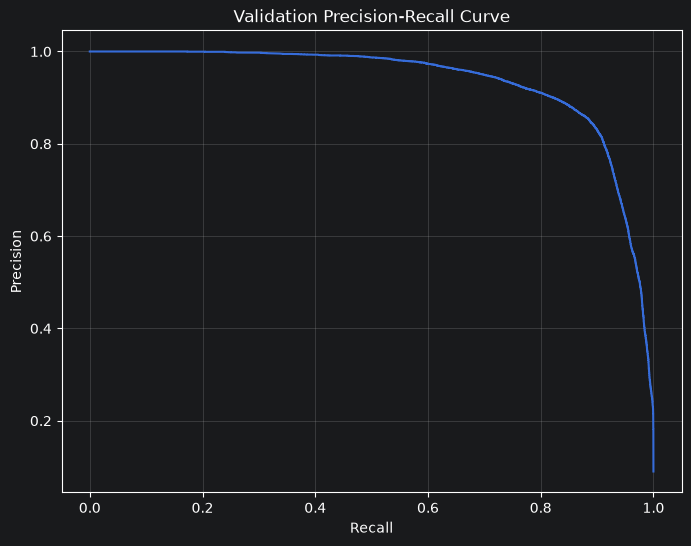

In [25]:
precision, recall, _ = (
    precision_recall_curve(
        validation_predictions[
            "is_churn"
        ],

        validation_predictions[
            "churn_probability"
        ],
    )
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    recall,
    precision,
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Validation Precision-Recall Curve"
)

plt.grid(
    alpha=0.3
)

plt.show()


---

## 4. ROC Curve


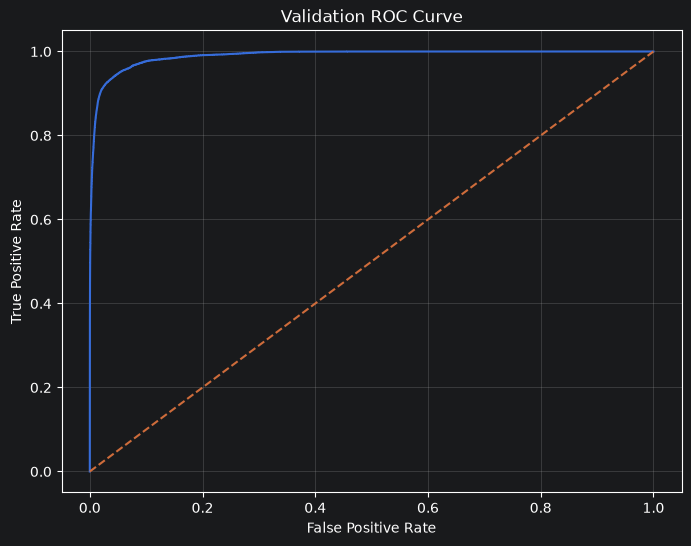

In [26]:
fpr, tpr, _ = roc_curve(
    validation_predictions[
        "is_churn"
    ],

    validation_predictions[
        "churn_probability"
    ],
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    fpr,
    tpr,
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Validation ROC Curve"
)

plt.grid(
    alpha=0.3
)

plt.show()


---

## 5. Threshold Analysis


In [27]:
threshold_table.describe()


,threshold,precision,recall,f1
count,119501.0000,119501.0000,119501.0000,119501.0000
mean,0.1618,0.3244,0.9420,0.3980
std,0.3044,0.2707,0.1705,0.2072
min,0.0000,0.0899,0.0001,0.0002
25%,0.0007,0.1345,0.9834,0.2315
50%,0.0105,0.2033,0.9996,0.3267
75%,0.0899,0.4077,1.0000,0.5334
max,1.0000,1.0000,1.0000,0.8692


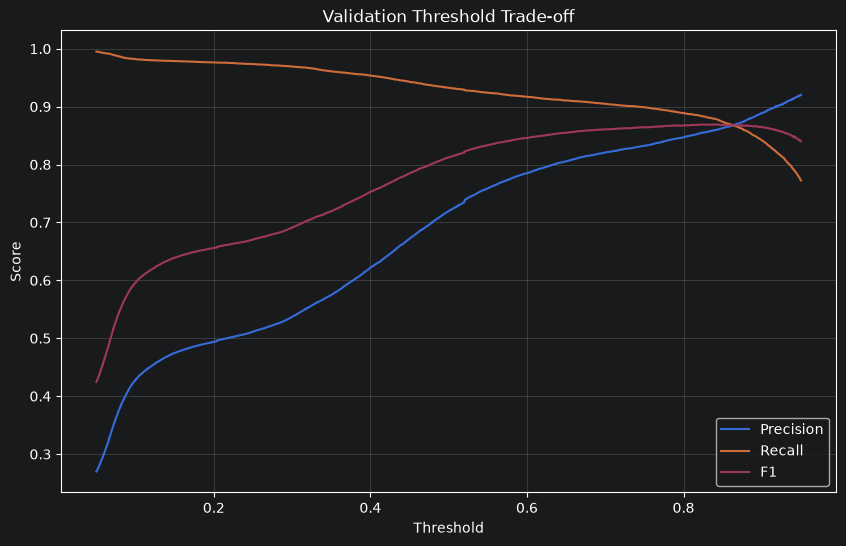

In [28]:
plot_thresholds = (
    threshold_table[
        threshold_table[
            "threshold"
        ].between(
            0.05,
            0.95,
        )
    ]
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    plot_thresholds[
        "threshold"
    ],

    plot_thresholds[
        "precision"
    ],

    label="Precision",
)

plt.plot(
    plot_thresholds[
        "threshold"
    ],

    plot_thresholds[
        "recall"
    ],

    label="Recall",
)

plt.plot(
    plot_thresholds[
        "threshold"
    ],

    plot_thresholds[
        "f1"
    ],

    label="F1",
)

plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Validation Threshold Trade-off"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


---

## 6. Threshold Strategy Comparison


In [29]:
threshold_comparison = (
    pd.DataFrame(
        [
            {
                "strategy":
                    "threshold_0_5",

                **evaluation_results[
                    "validation"
                ][
                    "threshold_0_5"
                ],
            },

            {
                "strategy":
                    "max_f1",

                **evaluation_results[
                    "validation"
                ][
                    "max_f1"
                ],
            },

            {
                "strategy":
                    "recall_80",

                **evaluation_results[
                    "validation"
                ][
                    "recall_80"
                ],
            },
        ]
    )
)

threshold_comparison[
    [
        "strategy",
        "threshold",
        "precision",
        "recall",
        "f1",
        "fp",
        "fn",
        "predicted_positive_rate",
    ]
]


,strategy,threshold,precision,recall,f1,fp,fn,predicted_positive_rate
0,threshold_0_5,0.5000,0.7198,0.9325,0.8125,4756,884,0.1165
1,max_f1,0.8412,0.8597,0.8789,0.8692,1879,1587,0.0920
2,recall_80,0.9353,0.9108,0.8001,0.8518,1027,2619,0.0790


Đây là bảng quan trọng nhất trước khi chọn threshold.

---

### Threshold Selection

Ba scenario:

1. `threshold = 0.5`
2. Max Validation F1
3. Recall >= 80%

Nếu chưa có business constraint cụ thể, Max-F1 được sử dụng làm default threshold strategy.

Threshold chỉ được chọn bằng Validation.

Test không tham gia threshold selection.


---

## 7. Selected Model Configuration


In [30]:
with open(
    FINAL_MODEL_CONFIG_PATH,
    encoding="utf-8",
) as file:
    model_config = (
        json.load(file)
    )

pd.Series(
    model_config
)


model                                                            lightgbm
model_path              /home/namdp/Documents/AI_Projects/kkbox-churn-...
threshold_strategy                                      max_validation_f1
threshold                                                          0.8412
calibration_strategy                                                 none
primary_metric                                                     pr_auc
locked                                                               True
dtype: object

Sau `--validation-only`, bạn sẽ thấy:

```text
locked = False
```

Đó là đúng.


In [31]:
final_comparison = pd.DataFrame(
    {
        "metric": [
            "PR-AUC",
            "ROC-AUC",
            "Brier Score",
            "Precision",
            "Recall",
            "F1",
        ],

        "validation": [
            0.9344557863761336,
            0.9897519072450893,
            0.032100620002908385,
            0.8596923536439666,
            0.878854961832061,
            0.8691680507322965,
        ],

        "test": [
            0.9361119795610258,
            0.9903364443670254,
            0.031854462558351594,
            0.8591174514006948,
            0.8873196427208184,
            0.8729908367132342,
        ],
    }
)

final_comparison

,metric,validation,test
0,PR-AUC,0.9345,0.9361
1,ROC-AUC,0.9898,0.9903
2,Brier Score,0.0321,0.0319
3,Precision,0.8597,0.8591
4,Recall,0.8789,0.8873
5,F1,0.8692,0.8730


In [32]:
final_comparison[
    "test_minus_validation"
] = (
    final_comparison["test"]
    - final_comparison["validation"]
)

final_comparison

,metric,validation,test,test_minus_validation
0,PR-AUC,0.9345,0.9361,0.0017
1,ROC-AUC,0.9898,0.9903,0.0006
2,Brier Score,0.0321,0.0319,-0.0002
3,Precision,0.8597,0.8591,-0.0006
4,Recall,0.8789,0.8873,0.0085
5,F1,0.8692,0.8730,0.0038


## Final Test Findings

Final model:

- Model: **LightGBM**
- Threshold strategy: **Max Validation F1**
- Threshold: **0.8412**

Final Test performance:

- PR-AUC: **0.9361**
- ROC-AUC: **0.9903**
- Precision: **0.8591**
- Recall: **0.8873**
- F1-score: **0.8730**
- Brier Score: **0.0319**

Final Test confusion matrix:

- True Negative: **130,639**
- False Positive: **1,906**
- False Negative: **1,476**
- True Positive: **11,623**

Test performance is very close to Validation performance. No material degradation is observed when moving from Validation to the previously unseen Test set.

This indicates that the selected LightGBM model generalizes well to unseen users.

The final threshold was selected exclusively using Validation data and was locked before Test evaluation. Test results were not used for model selection, hyperparameter tuning, or threshold optimization.